<div align="center">

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/xiangtgao/DS-UA_201-Causal-Inference-Spring-2025/blob/main/labs/4-Statistics_and_Experiments.ipynb)

</div>





$$
\begin{array}{c}
\textbf{CAUSAL INFERENCE}\\\\
\textbf{Hamza Alshamy} \\
\textit{Center for Data Science, New York University} \\\\
\textit{Sep 26, 2025}\\\\\\
\text{Materials prepared by: Daniela Pinto Veizaga, Xiang Pan, and Xiang Gao}
\end{array}
$$

---

# Hypothesis testing and Introduction to Experiments

## Goals for today

**1. Hypothesis Testing**
- One-sided vs Two-sided
- P-values
- Type 1 and Type 2 Errors
- Confidence Intervals

**2. Experiments**
- An introduction.


## (1) Hypothesis Testing

![alt text](Images/hypothesis_testing.png "Titles")


![alt text](Images/null_alternative.png "title")


A key goal in causal inference is to make informed decisions based on sample data. Hypothesis testing helps us decide whether to **reject** or **fail to reject** a claim about a population parameter based on evidence from our data.

### Key Concepts

1. **Null Hypothesis ($H_0$)**:  
   Represents the default assumption we aim to **disprove**. For example, in a medical trial, it might state that a new treatment has no effect.

2. **Alternative Hypothesis ($H_1$)**:  
   What we want to **prove** through analysis, proposing an outcome different from $H_0$. For instance, it may claim that the new treatment **does** have an effect.

3. **Test Statistic ($T_n$)**:  
   A measure of how far our sample data deviates from expectations under $H_0$, quantifying the strength of evidence against it.

4. **Critical Value ($c$)**:  
   A threshold defining what is “significant” evidence. If our test statistic exceeds this value, we reject $H_0$.

5. **Decision Rule**:  
   If the test statistic is greater than the $c$, we reject $H_0$ in favor of $H_1$. If it's less than or equal to the critical value, we **fail to reject** $H_0$. Note that failing to reject $H_0$ does not prove it true; it just indicates insufficient evidence against it.

> **Significance** ($\alpha$) and **P-Value**: A result is considered **significant** if the evidence against $H_0$ is strong. The **p-value** measures this evidence. It indicates the probability of observing data as extreme as ours if $H_0$ were true. A low p-value (typically < 0.05) suggests strong evidence against $H_0$.


Now, let's apply our hypothesis testing framework by simulating a dataset and examining the results.

### Simulation

**a) Simulate a Dataset**

We'll start by generating a dataset from a normal distribution, specifically $X \sim N(5, 1.5)$.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from IPython.display import display, Math

In [10]:
np.random.seed(42)
mu, sigma= 5.0, 1.5
sample = np.random.normal(loc=mu, scale=sigma, size=1000)

In [11]:
sample[:10]

array([5.74507123, 4.79260355, 5.97153281, 7.28454478, 4.64876994,
       4.64879456, 7.36881922, 6.15115209, 4.29578842, 5.81384007])

In [12]:
n = len(sample)
sample_mean = np.mean(sample)
sample_std = np.std(sample)

**b) Define our hypothesis**

Our null hypothesis ($H_0$) states that the population mean is equal to 8. The alternative hypothesis ($H_1$) suggests that the mean is different from this value.





$$H_0: \mathbb{E}[X] = \mu =8, \quad H_1: \mathbb{E}[X] \neq 8.$$



In [16]:
mu_0=8

#### One-sided vs Two-sided Test




**Two-Sided Test**
- **Hypotheses**:  
  $$H_0: \mu = \mu_0, \quad H_1: \mu \neq \mu_0$$
- **Logic**: We only care whether the mean is *different* from $\mu_0$, in either direction.  
- **Rejection region**: Both tails of the distribution.  
- **Example**: Testing if the average exam score is different from 70 (could be higher *or* lower).  



**One-Sided Test**
- **Hypotheses (two possible forms)**:  
  - Upper-tailed:  
    $$H_0: \mu = \mu_0, \quad H_1: \mu > \mu_0$$
  - Lower-tailed:  
    $$H_0: \mu = \mu_0, \quad H_1: \mu < \mu_0$$
- **Logic**: We expect the mean to be *larger* (or *smaller*), not just different.  
- **Rejection region**: Only one tail of the distribution.  
- **Example**: Testing if a new fertilizer increases crop yield compared to the standard (we only care if it’s higher, not lower).  

**Simple takeaway**:  
- **Two-sided test** → “Is it different?”  
- **One-sided test** → “Is it bigger (or smaller)?”  

![alt text](Images/one_sided_two_sided.png "Two Sided vs One-Sided")


This figure shows the rejection regions for hypothesis tests using the t-distribution.

- The **gray region (1 − α)** is where we *fail to reject* the null hypothesis. These are values of the test statistic that are plausible if $H_0$ is true.  
- The **red regions (α)** are the **critical regions**, where the results are so extreme that they are unlikely under $H_0$. If the test statistic falls here, we reject $H_0$. 
    - The red shaded α is just the percentage of extreme values we’re willing to call ‘unlikely’ under the null. For a two-sided test at 5%, that’s 2.5% in each tail. For a one-sided test at 5%, that’s all 5% in one tail. The cutoff t-value is the point where the red area begins.”

**Two-sided test (left):**  
- Alternative hypothesis: $H_1: \mu \neq \mu_0$  
- We split α equally across both tails ($\alpha/2$ each).  
- Evidence against $H_0$ can come from either very large or very small values of the test statistic.  

**One-sided tests (right):**  
- Alternative hypothesis: $H_1: \mu > \mu_0$ → rejection region in the **right tail** (upper α).  
- Alternative hypothesis: $H_1: \mu < \mu_0$ → rejection region in the **left tail** (lower α).  
- Here, evidence against $H_0$ only comes from one direction, depending on the alternative.  


**c)  Set a significance level $\alpha$**

The significance level $\alpha$ is the threshold we set for deciding how much evidence we need to reject $H_0$. It represents the risk we are willing to accept for falsely rejecting the $H_0$ (Type I error). Common choices for 𝛼 are 0.05 or 0.01. This means we are willing to accept a 5% or 1% chance of making an error.

In [13]:
# Significance level
alpha=0.05

**d) Compute Test Statistic $T_n$**

To quantitatively assess whether our sample provides enough evidence to reject $H_0$, we use the t-test statistic:

$$T_n = \frac{|\overline{X}_n - \mu_0|}{\hat{\sigma}/\sqrt{n}}$$

$T_n$ measures how far our sample mean ($\overline{X_n}$) is from the hypothesized mean ($\mu_0$). The larger the value of $T_n$, the more evidence we have against the null hypothesis ($H_0$).

> Recall that, as the sample size  $n$ increases, the distribution of the sample mean $\bar{X_n}$ approaches normality due to the Central Limit Theorem (CLT):

$$
\bar{X_n} \sim N(\mu, \frac{\sigma}{\sqrt{n}})
$$

This implies,

$$
T_n \sim N(0, 1).
$$

This property enables the use of normal distribution properties to derive critical values, calculate p-values, and make informed decisions based on statistical evidence.


---
**How?**

- Under the null hypothesis, we assume under $H_0$:  

$$\mu = \mu_{0}$$


So:  

$$\overline{X}_n - \mu_0 \sim N\left(0,\frac{\sigma}{\sqrt{n}}\right).$$




- We can standardize

Whenever you have a normal random variable $Y \sim N(\mu, \sigma)$, you can standardize it by subtracting the mean and dividing by the standard deviation:  

$$
Z = \frac{Y - \mu}{\sigma} \sim N(0,1)
$$

Apply this here with. Then:

$$T_n = \frac{\overline{X}_n - \mu_0}{\sigma/\sqrt{n}} \sim N(0,1).$$

**Key point:** The whole point of dividing by the standard error is that it makes the test statistic follow a standard form (Z or T). That’s why we can look up cutoffs in a table and make a decision.

In [14]:
def compute_test_statistic(sample_mean, sample_std, mu_0):
    T_n = np.sqrt(n) * abs(sample_mean - mu_0) / sample_std
    return T_n

In [17]:
T_n = compute_test_statistic(sample_mean, sample_std, mu_0)
display(Math(f"T_n: {T_n}"))

<IPython.core.display.Math object>

We can also run the same test using a pre-built function from `scipy`.  

The function `stats.ttest_1samp` automatically calculates the test statistic and p-value for a one-sample t-test:  

In [18]:
# Run a one-sample t-test:
t_stat, p_value = stats.ttest_1samp(sample, mu_0)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: -63.963644257344804
p-value: 0.0


Notice that our manual calculation gave a positive number because we took the absolute value, while `scipy` preserves the sign. For **two-sided tests** the sign does not matter, but for **one-sided tests** it tells us which tail of the distribution we are in.  

**e) Define the critical value $c$**

**Definition**  
The *critical value* is the cutoff point that separates the region where we *fail to reject* $H_0$ from the region where we *reject* $H_0$.  

**What it means**  
- If the test statistic falls inside the critical value (the gray region), the result is consistent with $H_0$.  
- If the test statistic falls beyond the critical value (the red tails), the result is too unlikely under $H_0$, so we reject it.  

**To determine the critical value $c$, we want to find the value such that:**
$$
2\big(1 - \Phi(c)\big) = \alpha,
$$

where $\Phi$ is the CDF of the standard normal distribution. The factor of 2 accounts for the two-sided nature of our test. For more details on how this was derived, please refer to lecture notes.

- Rearranging this equation helps us find $\Phi(c) $:

   $$
   \Phi(c) = 1 - \frac{\alpha}{2}
   $$

- We are essentially asking: *Choose $c$ so that the probability of being below $c$ in the standard normal is $1 - \frac{\alpha}{2}$”*  


This gives us the critical value that corresponds to our chosen $\alpha$.


In [19]:
critical_value = stats.norm.ppf(1 - alpha / 2)
display(Math(f"\\text{{For }} \\alpha = {alpha}, \\text{{the critical value}} \, c \,\\text{{is}} \, {round(critical_value, 2)}"))


<IPython.core.display.Math object>

![alt text](Images/z-stat.webp "title")


**P-Value $p_n$**

To measure the strength of evidence against the null hypothesis ($H_0$), we estimate the p-value $\hat{p_n}$:

$$
\hat{p_n} = 2(1 - \Phi(T_n)).
$$

This p-value tells us the smallest significance level $\alpha$ at which we would reject $H_0$. If $T_n$ is large, $\hat{p_n}$ will be small, indicating strong evidence against $H_0$. A smaller p-value means the observed data is very unlikely under the null hypothesis.

In [20]:
def compute_p_value(T_n):
    p_value = 2 * (1 - stats.norm.cdf(T_n))
    return p_value

In [23]:
p_value = compute_p_value(T_n)
display(Math(f"\\hat p_n = {round(p_value, 10)}"))

<IPython.core.display.Math object>

A **p-value of 0.0** (or very close to 0) suggests **strong evidence against the null hypothesis**. In other words, the difference between the sample mean and the population mean is statistically significant.

* Typically, if the p-value is below a chosen significance level (e.g., 0.05), we reject the null hypothesis.

Alternatively, we could use a predefined function within the SciPy library to perform a one-sample t-test.

In [24]:
stats.ttest_1samp(sample, mu_0)

TtestResult(statistic=np.float64(-63.963644257344804), pvalue=np.float64(0.0), df=np.int64(999))

In [25]:
stats.t.ppf(q=0.025, df=n-1)

np.float64(-1.962341461133449)

In [26]:
stats.t.ppf(q=0.975, df=n-1)

np.float64(1.9623414611334487)

### Confidence Intervals
- Moving from point estimates to interval estimates

For a two-sided test, the confidence interval is given by:
$$
C_n = \left[
\underbrace{\overline{X}_n}_{\text{estimate}}
\;\; \pm \;\;
\underbrace{\frac{\hat{\sigma}_n}{\sqrt{n}} \; \Phi^{-1}\!\left(1 - \frac{\alpha}{2}\right)}_{\text{margin of error}}
\right]
$$

where $\frac{\hat{\sigma}_n}{\sqrt{n}} \Phi^{-1}\left(1 - \frac{\alpha}{2}\right)$ represents the margin of error around the sample mean.

This interval will give us a range of values that, with a certain level of confidence (typically 95%), is likely to contain the true population mean.

In [27]:
def compute_confidence_interval(sample_mean, sample_std, n, alpha):
    z_critical = stats.norm.ppf(1 - alpha / 2)
    margin_of_error = z_critical * (sample_std / np.sqrt(n))
    confidence_interval = (sample_mean - margin_of_error, sample_mean + margin_of_error)
    return confidence_interval

In [28]:
confidence_interval = compute_confidence_interval(sample_mean, sample_std, n, alpha)
print(f"95% Confidence Interval: {confidence_interval}")

95% Confidence Interval: (np.float64(4.9380066375012746), np.float64(5.119989529965702))



Finally, we can visualize the results using a plot that includes the simulated sample, the sample mean, the hypothesized mean, and the confidence interval.


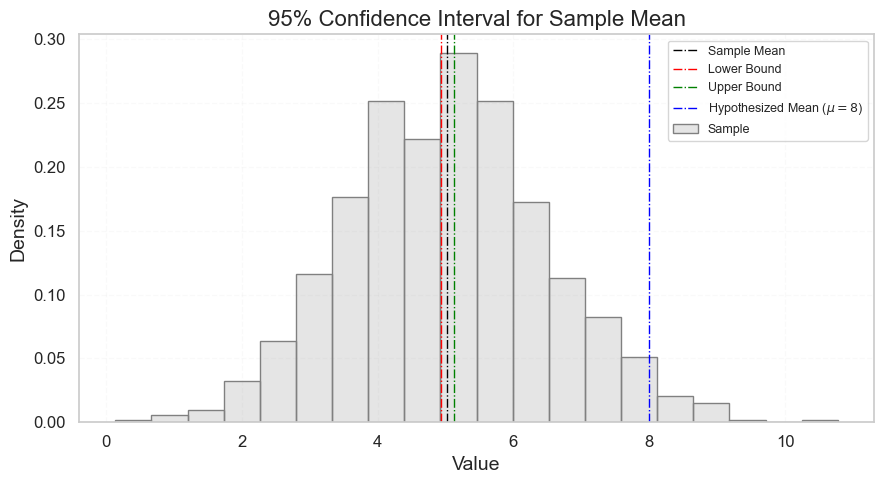

In [18]:
sns.set(style='whitegrid', palette='deep')
plt.figure(figsize=(9, 5))
sns.histplot(sample, bins=20, stat="density", color='grey', edgecolor='grey', alpha=0.2, label='Sample')
plt.axvline(np.mean(sample), color='black', linestyle='-.', linewidth=1, label="Sample Mean")
plt.axvline(confidence_interval[0], color='red', linestyle='-.', linewidth=1, label="Lower Bound")
plt.axvline(confidence_interval[1], color='green', linestyle='-.', linewidth=1, label="Upper Bound")
plt.axvline(mu_0, color='blue', linestyle='-.', linewidth=1, label="Hypothesized Mean ($\mu = 8$)")
plt.title("95% Confidence Interval for Sample Mean", fontsize=16)
plt.xlabel("Value", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.1)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()


We only have one sample, but because we know how the sample mean behaves across repeated samples, we can construct an interval that, if we repeated the sampling many times, would succeed 95% of the time. That’s why even from one sample, we can be 95% confident in our interval

### Type 1 and Type 2 Errors

![alt text](Images/errors.png "title")

- **Type I Error** (false positive): A person is innocent, but the court convicts them (they go to jail).  
  - In hypothesis test terms: rejecting $H_0$ when $H_0$ is true.  

- **Type II Error** (false negative): A patient has cancer, but the test fails to detect it (diagnosed as healthy).  
  - In hypothesis test terms: failing to reject $H_0$ when $H_0$ is false.  


## (2) Experiments

- Difference between observational data and experiments (RCTs)


Let's say we want to understand the effect of a job training program (S) on wages (Y) (example seen last lecture). To estimate this causal effect, the government launches a survey asking households if they've participated in job training programs through public libraries or other resources.

> Can we truly estimate causal effects from this data? How could unmeasured factors ($U$), influence our estimates? Consider how these factors can complicate our understanding of the true impact of job training on wages.


Let’s visualize this in an observational setting using a Directed Acyclic Graph (DAG), where our outcome of interest is wage (\(Y\)).

In [19]:
import networkx as nx

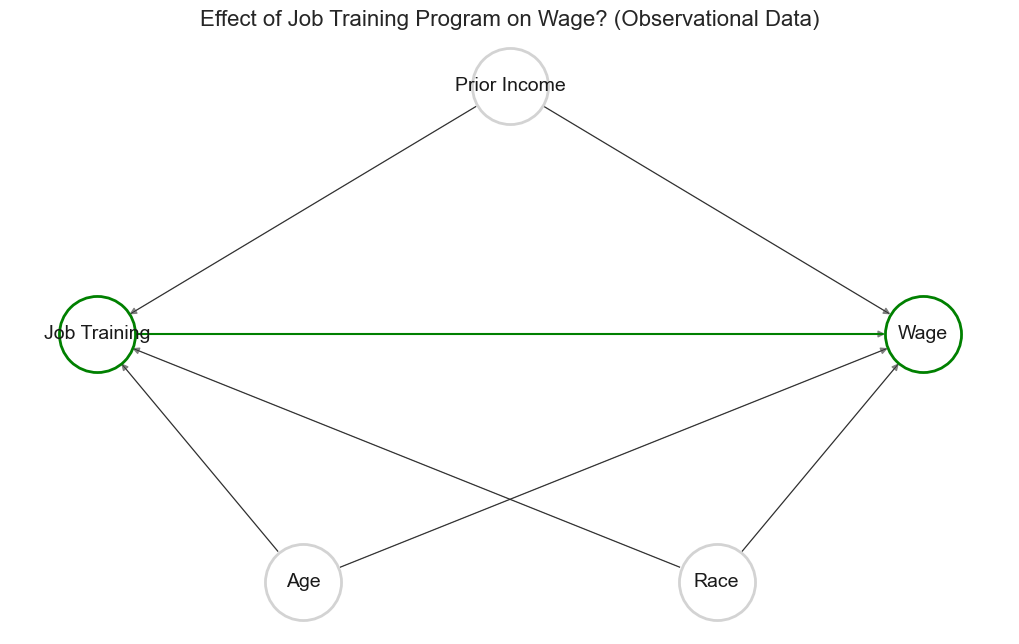

In [20]:
G = nx.DiGraph()

edges = [
    ('Job Training', 'Wage'),
    ('Age', 'Job Training'),
    ('Age', 'Wage'),
    ('Race', 'Job Training'),
    ('Race', 'Wage'),
    ('Prior Income', 'Job Training'),
    ('Prior Income', 'Wage'),
]

G.add_edges_from(edges)

pos = {
    'Job Training': (1, 2),
    'Wage': (5, 2),
    'Age': (2, 1),
    'Race': (4, 1),
    'Prior Income': (3, 3)
}
node_colors = ['white' for _ in G.nodes()]
outline_colors = ['green' if node in ['Wage', 'Job Training'] else 'lightgray' for node in G.nodes()]

plt.figure(figsize=(10, 6))
nx.draw(G, pos, with_labels=True, arrows=True, node_size=3000, node_color=node_colors, font_size=14, edge_color='gray', linewidths=2)

for node, color in zip(G.nodes(), outline_colors):
    nx.draw_networkx_nodes(G, pos, nodelist=[node], node_color='white', edgecolors=color, linewidths=2, node_size=3000)

for edge in edges:
    if edge == ('Job Training', 'Wage'):
        nx.draw_networkx_edges(G, pos, edgelist=[edge], width=1.5, edge_color='green')
    else:
        nx.draw_networkx_edges(G, pos, edgelist=[edge], width=0.5)

plt.title('Effect of Job Training Program on Wage? (Observational Data)', fontsize=16)
plt.gca().set_facecolor('whitesmoke')
plt.axis('off')  # Turn off the axis
plt.grid(False)  # Turn off grid
plt.show()



Here:

- $ U $ represents confounding factors such as education, experience, and socioeconomic status. These factors influence both the likelihood of participating in the job training program ($ S $) and the wages or income ($ Y $).
- The arrow from $ U $ to $ S $ indicates that individuals with higher education or more experience are more likely to enroll in job training programs.
- $ U $ affects $ Y $ because education and experience are key determinants of wages.
- Participation in the job training program ($ S $) directly influences wages ($ Y $), as the training may enhance skills and lead to higher income.

*Confounding bias* occurs because the relationship from $ S $ to $ Y $ is affected by $ U $. This makes it difficult to separate the true impact of the training ($ S $) from the influence of the confounding factors ($ U $).

As a result, we might observe that the average wage for participants in the training is lower than the average wage for the broader population that could benefit from such training:

$$ \mathbb{E}[Y(S = 1, U)|S = 1] < \mathbb{E}[Y(S = 1, U)], $$

causing the job training program to appear less effective than it truly is.

To address this issue, we use randomized controlled trials (RCTs) to isolate the effect of the training. By randomizing treatment assignment, and assuming:
 + Perfect compliance, and
 + SUTVA

we ensure $ S \perp U $.

**Note, while $ S $ still directly affects $ Y $, and $ U $ continues to influence $ Y $ (since factors like education and experience impact wages), $ U $ no longer has any effect on $ S $.**




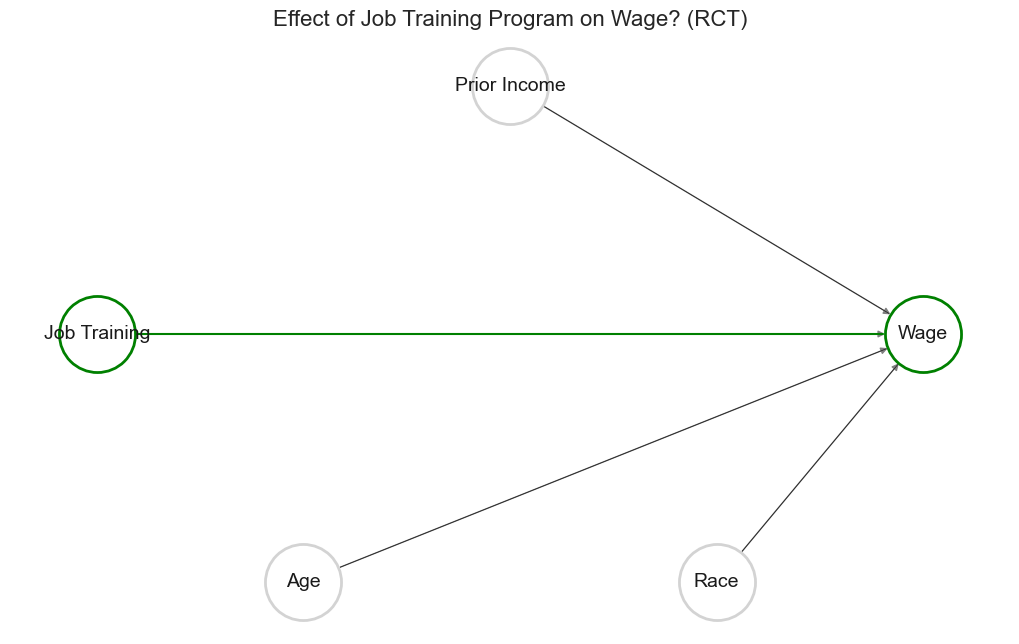

In [21]:
G = nx.DiGraph()

edges = [
    ('Job Training', 'Wage'),
    ('Age', 'Wage'),
    ('Race', 'Wage'),
    ('Prior Income', 'Wage'),
]

G.add_edges_from(edges)

pos = {
    'Job Training': (1, 2),
    'Wage': (5, 2),
    'Age': (2, 1),
    'Race': (4, 1),
    'Prior Income': (3, 3)
}
node_colors = ['white' for _ in G.nodes()]
outline_colors = ['green' if node in ['Wage', 'Job Training'] else 'lightgray' for node in G.nodes()]

plt.figure(figsize=(10, 6))
nx.draw(G, pos, with_labels=True, arrows=True, node_size=3000, node_color=node_colors, font_size=14, edge_color='gray', linewidths=2)

for node, color in zip(G.nodes(), outline_colors):
    nx.draw_networkx_nodes(G, pos, nodelist=[node], node_color='white', edgecolors=color, linewidths=2, node_size=3000)

for edge in edges:
    if edge == ('Job Training', 'Wage'):
        nx.draw_networkx_edges(G, pos, edgelist=[edge], width=1.5, edge_color='green')
    else:
        nx.draw_networkx_edges(G, pos, edgelist=[edge], width=0.5)

plt.title('Effect of Job Training Program on Wage? (RCT)', fontsize=16)
plt.gca().set_facecolor('whitesmoke')
plt.axis('off')  # Turn off the axis
plt.grid(False)  # Turn off grid
plt.show()

After randomization, assuming perfect compliance and SUTVA:

- The average outcome in the treatment group is equal to that of the overall population receiving treatment:
  
  $$
  E[Y(S = 1, U) | S = 1] = E[Y(S = 1, U)].
  $$

- The average outcome in the control group matches that of the overall population without treatment:
  
  $$
  E[Y(S = 0, U) | S = 0] = E[Y(S = 0, U)].
  $$

This implies that, despite the fundamental problem of causal inference, we can estimate the Average Treatment Effect (ATE) since there are no systematic differences between groups. Thus, we can express the ATE as:
  
$$
ATE = E[Y(S = 1, U) | S = 1] - E[Y(S = 0, U) | S = 0].
$$


---

**References:**


[^1]: Lalonde, R. J. (1986). *Evaluating the Econometric Evaluations of Training Programs with Experimental Data.* American Economic Review, 76(4), 604-620.
